In [5]:
%pip install pandas numpy matplotlib seaborn scikit-learn
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

# Definindo os nomes das colunas com base no arquivo adult.names
colunas = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Carregando o dataset
# Usamos skipinitialspace=True porque o dataset original possui espaços após as vírgulas
df = pd.read_csv('.venv/adult.data', names=colunas, skipinitialspace=True)

# Visualizando as primeiras linhas
display(df.head())

# Verificando o formato e tipos de dados
print("\n--- Informações do Dataset ---")
df.info()

# Resumo estatístico das variáveis numéricas
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

Note: you may need to restart the kernel to use updated packages.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

--- Estatísticas Descritivas ---


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
Parte 1: O uso de skipinitialspace=True é essencial aqui, pois os dados vêm com espaços em branco antes das strings (ex: " <=50K" em vez de "<=50K"). 
Nisso o método info() nos mostrará que temos 32.561 linhas. Variáveis como age, fnlwgt, education-num, capital-gain, capital-loss e hours-per-week são numéricas (int64),
enquanto as demais são categóricas (object).

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11532\1114982415.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


Variáveis Numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Variáveis Categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

--- Valores Ausentes por Coluna ---
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


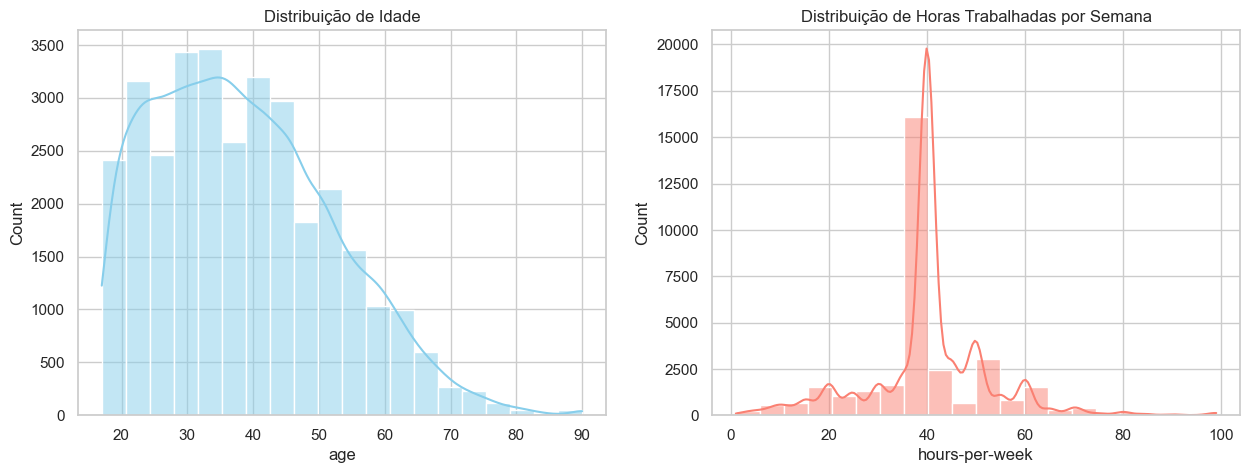

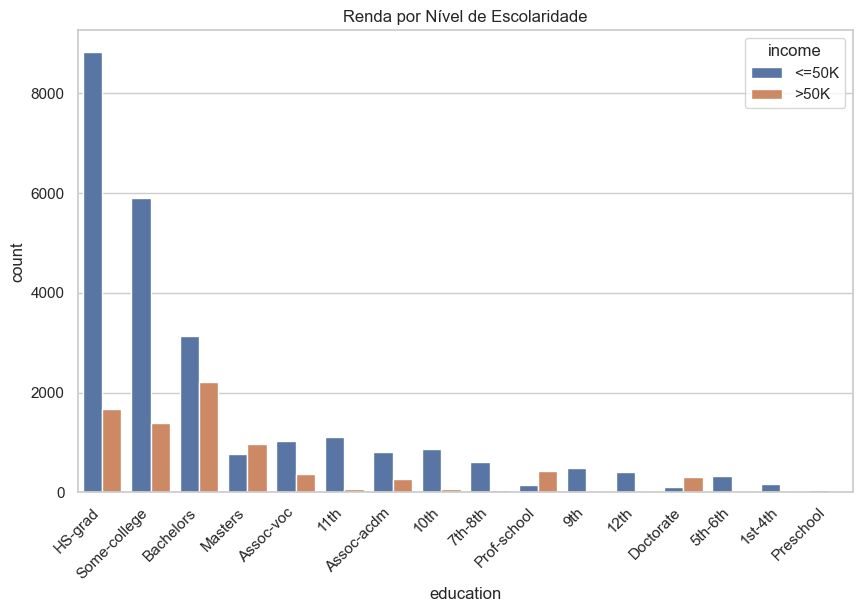

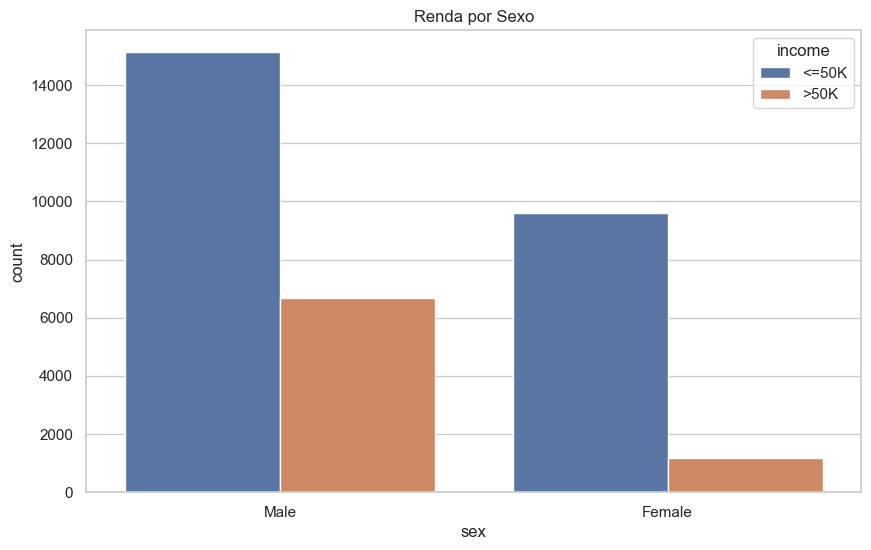

In [6]:
# 2.1 Tipos de variáveis
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variáveis Numéricas: {num_cols}")
print(f"Variáveis Categóricas: {cat_cols}")

# 2.2 Valores ausentes ou inconsistentes
# O dataset usa '?' para dados faltantes. Vamos converter para NaN para facilitar a contagem.
df.replace('?', np.nan, inplace=True)

print("\n--- Valores Ausentes por Coluna ---")
print(df.isnull().sum())

# 2.3 Distribuições
plt.figure(figsize=(15, 5))

# Distribuição de Idade
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribuição de Idade')

# Distribuição de Horas Trabalhadas por Semana
plt.subplot(1, 2, 2)
sns.histplot(df['hours-per-week'], bins=20, kde=True, color='salmon')
plt.title('Distribuição de Horas Trabalhadas por Semana')
plt.show()

# 2.4 Relações com a variável alvo (income)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', hue='income', order=df['education'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Renda por Nível de Escolaridade')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sex', hue='income')
plt.title('Renda por Sexo')
plt.show()

In [ ]:
Parte 2: 
Inconsistências: identificamos que ás variaveis workclass, occupation e native-country possuem valores ausentes representados por '?'. Nol caso elas foram substituidas por NoN.
Distribuição: A idade está concentrada entre 20 e 40 anos. As horas de trabalho têm um pico alto em 40 horas semanais.
Relação com Income: É notavel que niveis mais altos de escolaridade possuem uma proporção maior de pessoas ganhando mais de 50K. O mesmo ocorre com a variável occupation, onde profissões como Exec-managerial e Prof-specialty tem uma proporção maior de pessoas ganhando mais de 50K. Já a variável workclass não apresenta uma relação tão clara com o income, mas é possível observar que pessoas que trabalham por conta própria (Self-emp-not-inc e Self-emp-inc) tem uma proporção maior de pessoas ganhando mais de 50K em comparação com outras categorias.

In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_clean = df.copy()

# 3.1 Tratamento de valores ausentes
# Como a quantidade de '?' é relativamente pequena em relação ao total, podemos remover as linhas
# ou imputar com a moda (valor mais frequente). Aqui, optaremos pela imputação com a moda.
for col in ['workclass', 'occupation', 'native-country']:
    moda = df_clean[col].mode()[0]
    df_clean[col].fillna(moda, inplace=True)

# 3.2 Criação de variáveis derivadas (Opcional)
# Vamos agrupar as horas trabalhadas em categorias
bins = [0, 39, 40, 100]
labels = ['Part-time', 'Full-time', 'Overtime']
df_clean['work_hours_cat'] = pd.cut(df_clean['hours-per-week'], bins=bins, labels=labels)

# 3.3 Transformação da Variável Alvo
# Converter income para binário: '<=50K' -> 0, '>50K' -> 1
df_clean['income'] = df_clean['income'].map({'<=50K': 0, '>50K': 1})

# 3.4 Normalização/Padronização (Opcional)
# Aplicando StandardScaler nas variáveis numéricas
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Verificando o dataset final preparado
display(df_clean.head())

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11532\735228748.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(moda, inplace=True)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,work_hours_cat
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,0,Full-time
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,0,Part-time
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,0,Full-time
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,0,Full-time
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,0,Full-time


In [ ]:
Resumo: O dataset apresenta desbalanceamento na variável income, com cerca de 75% das pessoas recebendo até 50 mil anualmente. A carga horária de 40 horas semanais é predominante, e variáveis como escolaridade, ocupação e sexo masculino mostram forte relação com rendas  acima de 50 mil.
Também foi identificado que os valores ausentes estavam representados pelo caractere '?'. No pré-processamento, o caractere '?' foi substituído pop NaN, e os valores ausentes de workclass, occupation e native-country foram imputados com a moda de cada coluna. Além disso foi criada a variavél work]_hours_cat para categorizar as horas trabalhadas em faixas, facilitando a idenficação de padrões.
E por fim, a variavél alvo foi binarizada e ás variaveis numéricas foram padronizadas com StandardScaler para evitar impacto excessivo de atributos em escalas maiores no modelos de machine learning.